In [1]:
import pandas as pd

benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

benchmark.columns

Index(['date', 'index_name', 'close_value'], dtype='str')

In [2]:
nav = pd.read_csv("../data/raw/02_nav_history.csv")

nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='str')

In [3]:
performance = pd.read_csv("../data/raw/07_scheme_performance.csv")

performance.columns

Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')

In [4]:
# Merge NAV history with fund performance

df = nav.merge(
    performance,
    on="amfi_code",
    how="left"
)

df.head()

,amfi_code,date,nav,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,...,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,2022-01-03,54.3856,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,...,0.87,0.89,0.88,1.29,14.0,-21.7,14288,1.54,4,Moderate
1,119551,2022-01-04,54.3474,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,...,0.87,0.89,0.88,1.29,14.0,-21.7,14288,1.54,4,Moderate
2,119551,2022-01-05,54.6869,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,...,0.87,0.89,0.88,1.29,14.0,-21.7,14288,1.54,4,Moderate
3,119551,2022-01-06,55.4550,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,...,0.87,0.89,0.88,1.29,14.0,-21.7,14288,1.54,4,Moderate
4,119551,2022-01-07,55.3692,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,...,0.87,0.89,0.88,1.29,14.0,-21.7,14288,1.54,4,Moderate


In [5]:
df["date"] = pd.to_datetime(df["date"])

df["nav"] = pd.to_numeric(df["nav"])

In [6]:
df = df.sort_values(["amfi_code", "date"])

df["daily_return"] = (
    df.groupby("amfi_code")["nav"]
      .pct_change()
)

In [7]:
df.head(10)

,amfi_code,date,nav,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,...,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,daily_return
5750,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,...,0.97,1.06,1.7,14.0,-17.41,6434,1.55,5,Moderate,NaN
5751,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,...,0.97,1.06,1.7,14.0,-17.41,6434,1.55,5,Moderate,-0.010306
5752,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,...,0.97,1.06,1.7,14.0,-17.41,6434,1.55,5,Moderate,0.012865
5753,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,...,0.97,1.06,1.7,14.0,-17.41,6434,1.55,5,Moderate,-0.011377
5754,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,...,0.97,1.06,1.7,14.0,-17.41,6434,1.55,5,Moderate,-0.001210
5755,100016,2022-01-10,510.7136,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,...,0.97,1.06,1.7,14.0,-17.41,6434,1.55,5,Moderate,-0.008639
5756,100016,2022-01-11,513.5542,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,...,0.97,1.06,1.7,14.0,-17.41,6434,1.55,5,Moderate,0.005562
5757,100016,2022-01-12,512.3195,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,...,0.97,1.06,1.7,14.0,-17.41,6434,1.55,5,Moderate,-0.002404
5758,100016,2022-01-13,510.2445,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,...,0.97,1.06,1.7,14.0,-17.41,6434,1.55,5,Moderate,-0.004050
5759,100016,2022-01-14,514.3636,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,...,0.97,1.06,1.7,14.0,-17.41,6434,1.55,5,Moderate,0.008073


In [8]:
df["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

<Axes: title={'center': 'NAV Trend'}, xlabel='date'>

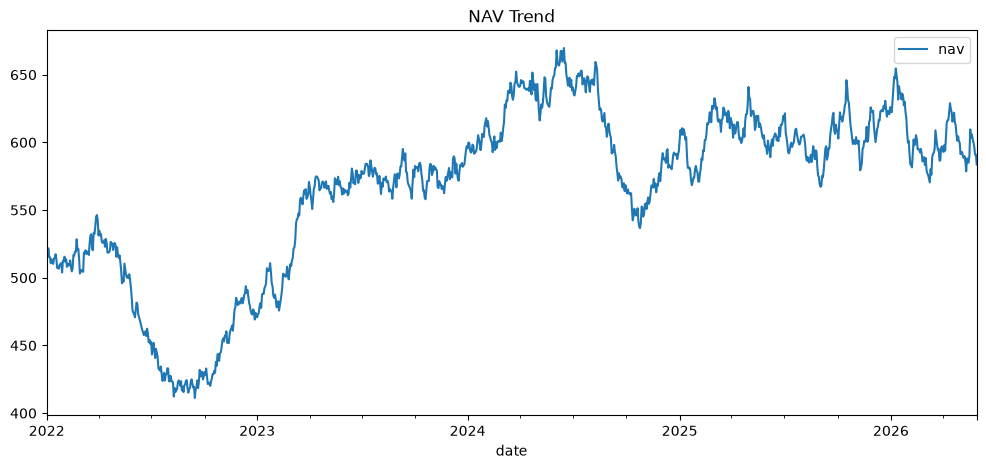

In [9]:
sample = df[df["amfi_code"] == df["amfi_code"].iloc[0]]

sample.plot(
    x="date",
    y="nav",
    figsize=(12,5),
    title="NAV Trend"
)

In [10]:
scorecard = performance.copy()

# Higher is better
scorecard["return_rank"] = scorecard["return_3yr_pct"].rank(ascending=False)
scorecard["sharpe_rank"] = scorecard["sharpe_ratio"].rank(ascending=False)
scorecard["alpha_rank"] = scorecard["alpha"].rank(ascending=False)

# Lower is better
scorecard["expense_rank"] = scorecard["expense_ratio_pct"].rank(ascending=True)
scorecard["drawdown_rank"] = scorecard["max_drawdown_pct"].rank(ascending=True)

n = len(scorecard)

# Convert ranks into scores out of 100
scorecard["return_score"] = (n - scorecard["return_rank"] + 1) / n * 100
scorecard["sharpe_score"] = (n - scorecard["sharpe_rank"] + 1) / n * 100
scorecard["alpha_score"] = (n - scorecard["alpha_rank"] + 1) / n * 100
scorecard["expense_score"] = (n - scorecard["expense_rank"] + 1) / n * 100
scorecard["drawdown_score"] = (n - scorecard["drawdown_rank"] + 1) / n * 100

scorecard["fund_score"] = (
      scorecard["return_score"]*0.30
    + scorecard["sharpe_score"]*0.25
    + scorecard["alpha_score"]*0.20
    + scorecard["expense_score"]*0.15
    + scorecard["drawdown_score"]*0.10
)

scorecard.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,return_score,sharpe_score,alpha_score,expense_score,drawdown_score,fund_score
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,...,26.5,32.0,30.5,19.5,37.5,36.25,22.50,26.25,53.75,34.1250
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,...,35.5,9.0,4.0,12.0,17.5,13.75,80.00,92.50,72.50,45.8125
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,18.0,20.0,21.0,33.0,100.0,57.50,52.50,50.00,20.00,64.3750
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,...,19.5,22.5,5.5,11.0,97.5,53.75,46.25,88.75,75.00,72.7500
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,...,5.0,13.0,9.0,39.0,7.5,90.00,70.00,80.00,5.00,51.2500


In [11]:
scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
)

scorecard.head(10)

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,...,sharpe_rank,alpha_rank,expense_rank,drawdown_rank,return_score,sharpe_score,alpha_score,expense_score,drawdown_score,fund_score
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,...,19.5,22.5,5.5,11.0,97.5,53.75,46.25,88.75,75.0,72.7500
22,120843,Kotak Flexicap Fund - Regular - Growth,Kotak Mahindra MF,Flexi Cap,Regular,15.74,15.65,13.50,13.80,1.85,...,12.0,3.5,22.0,21.0,75.0,72.50,93.75,47.50,50.0,71.5000
21,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra MF,Mid Cap,Regular,17.12,18.23,17.75,16.32,1.91,...,15.0,2.0,33.0,16.0,85.0,65.00,97.50,20.00,62.5,70.5000
29,101207,ABSL Small Cap Fund - Regular - Growth,Aditya Birla Sun Life MF,Small Cap,Regular,24.93,22.38,23.80,20.54,1.84,...,24.5,5.0,28.5,14.0,95.0,41.25,90.00,31.25,67.5,68.2500
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,...,18.0,20.0,21.0,33.0,100.0,57.50,52.50,50.00,20.0,64.3750
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Regular,15.12,14.81,12.68,13.19,1.62,...,7.5,12.0,23.0,26.0,60.0,83.75,72.50,45.00,37.5,63.9375
9,100025,HDFC Short Term Debt Fund - Regular - Growth,HDFC Mutual Fund,Short Duration,Regular,6.83,7.37,6.41,5.39,1.98,...,4.0,1.0,2.0,35.0,12.5,92.50,100.00,97.50,15.0,63.0000
14,120507,ICICI Pru Liquid Fund - Regular - Growth,ICICI Prudential MF,Liquid,Regular,8.89,7.68,7.94,5.83,1.85,...,1.0,3.5,7.0,38.0,15.0,100.00,93.75,85.00,7.5,61.7500
12,120505,ICICI Pru Midcap Fund - Regular - Growth,ICICI Prudential MF,Mid Cap,Regular,14.02,18.08,17.55,17.19,0.89,...,17.0,29.5,15.0,18.0,82.5,60.00,28.75,65.00,57.5,61.0000
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Large Cap,Direct,14.12,14.41,13.02,13.53,0.88,...,9.0,31.0,12.0,9.0,52.5,80.00,25.00,72.50,80.0,59.6250


In [12]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("Fund Scorecard Saved")

Fund Scorecard Saved


In [13]:
alpha_beta = scorecard[
    [
        "scheme_name",
        "alpha",
        "beta"
    ]
]

alpha_beta.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

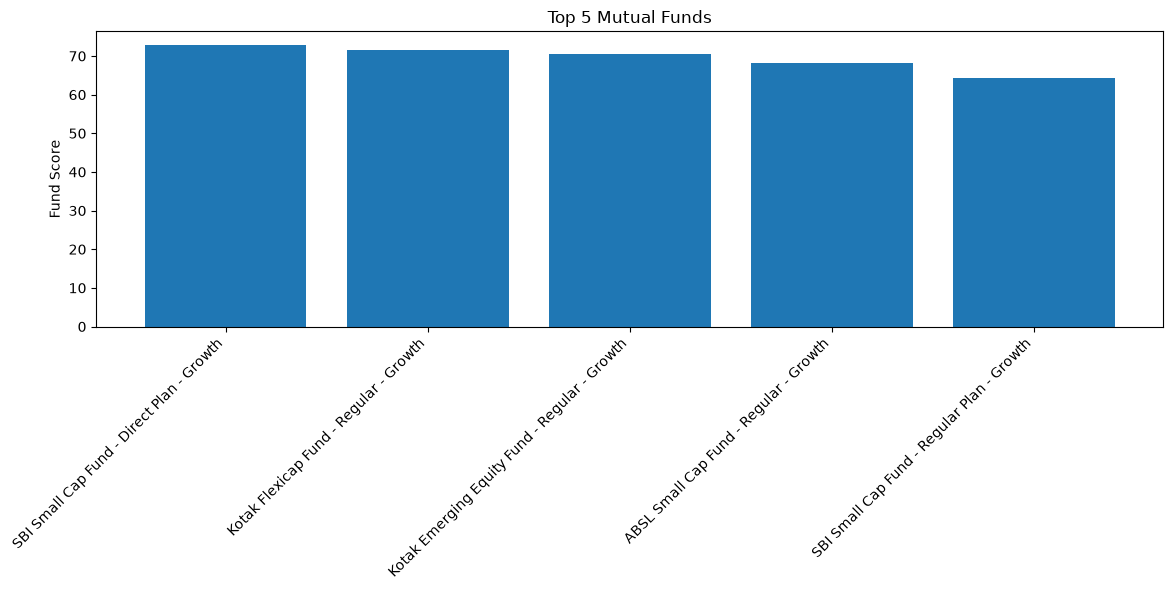

In [14]:
import matplotlib.pyplot as plt

top5 = scorecard.head(5)

plt.figure(figsize=(12,6))

plt.bar(
    top5["scheme_name"],
    top5["fund_score"]
)

plt.xticks(rotation=45, ha="right")

plt.ylabel("Fund Score")

plt.title("Top 5 Mutual Funds")

plt.tight_layout()

plt.savefig("../reports/top5_funds.png")

plt.show()

In [15]:
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

benchmark.head()

,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [16]:
benchmark["index_name"].unique()

<StringArray>
[        'NIFTY50',        'NIFTY100', 'NIFTY_MIDCAP150',    'BSE_SMALLCAP',
        'NIFTY500',   'CRISIL_LIQUID',     'CRISIL_GILT']
Length: 7, dtype: str

In [17]:
benchmark.info()

<class 'pandas.DataFrame'>
RangeIndex: 8050 entries, 0 to 8049
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         8050 non-null   str    
 1   index_name   8050 non-null   str    
 2   close_value  8050 non-null   float64
dtypes: float64(1), str(2)
memory usage: 188.8 KB


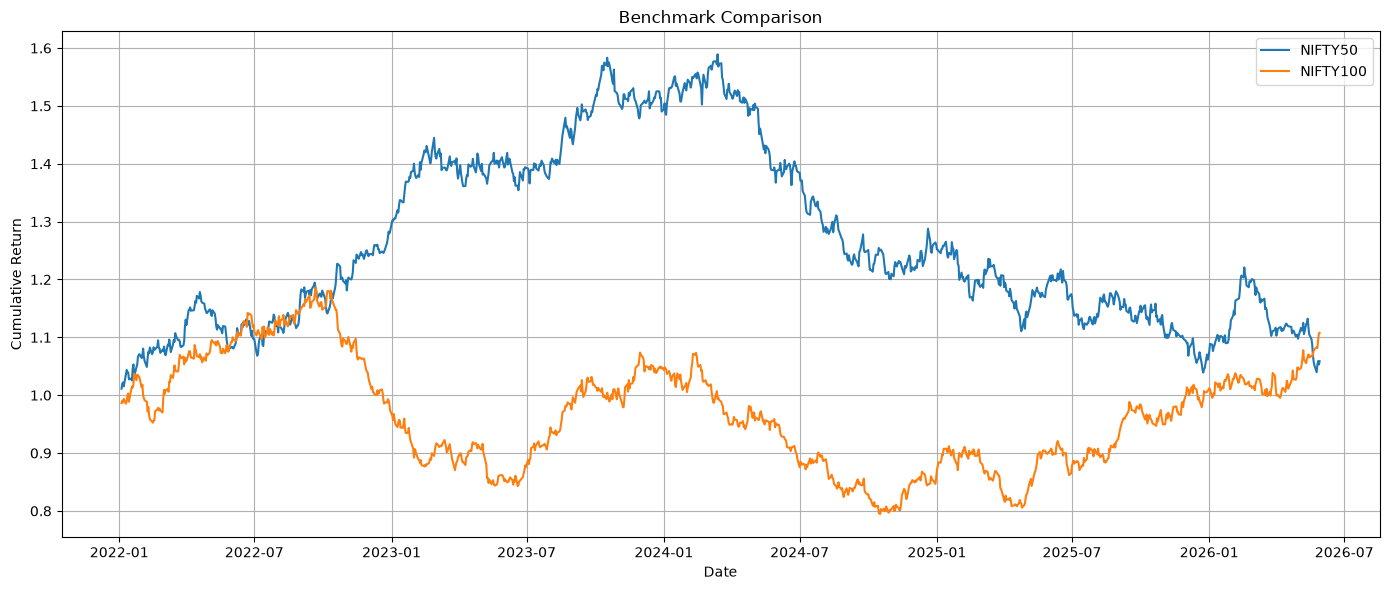

In [18]:
import matplotlib.pyplot as plt

# Convert dates
benchmark["date"] = pd.to_datetime(benchmark["date"])

# Keep only NIFTY50 and NIFTY100
benchmark_plot = benchmark[
    benchmark["index_name"].isin(["NIFTY50", "NIFTY100"])
].copy()

# Calculate cumulative return
benchmark_plot["daily_return"] = (
    benchmark_plot.groupby("index_name")["close_value"]
    .pct_change()
)

benchmark_plot["cumulative_return"] = (
    1 + benchmark_plot["daily_return"]
).groupby(benchmark_plot["index_name"]).cumprod()

plt.figure(figsize=(14,6))

for index in benchmark_plot["index_name"].unique():
    temp = benchmark_plot[
        benchmark_plot["index_name"] == index
    ]
    plt.plot(
        temp["date"],
        temp["cumulative_return"],
        label=index
    )

plt.title("Benchmark Comparison")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig("../reports/benchmark_comparison.png")

plt.show()

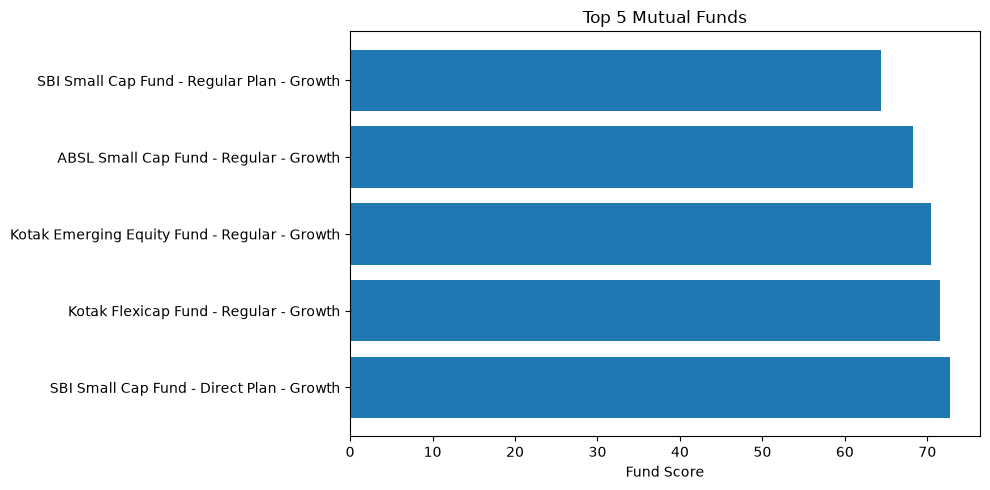

In [19]:
top5 = scorecard.head(5)

plt.figure(figsize=(10,5))

plt.barh(
    top5["scheme_name"],
    top5["fund_score"]
)

plt.xlabel("Fund Score")
plt.title("Top 5 Mutual Funds")

plt.tight_layout()

plt.savefig("../reports/top5_funds.png")

plt.show()

## Conclusion

- Daily returns were calculated from NAV history.
- Funds were ranked using weighted performance metrics.
- Alpha, Beta, Sharpe Ratio, Sortino Ratio and Maximum Drawdown were used for comparative analysis.
- A fund scorecard was generated to identify the highest-performing mutual funds.
- Benchmark comparison was performed against NIFTY50 and NIFTY100.

In [20]:
nav["amfi_code"].nunique()

40

In [21]:
nav["amfi_code"].unique()[:10]

array([119551, 119552, 119598, 119599, 119120, 100016, 125497, 100033,
       125498, 100025])